### Calculating the board

In [128]:
from ultralytics import YOLO
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [129]:
model_board = YOLO("../code/runs/segment/train6/weights/best.pt")

In [130]:
test_image_path = "../code/captured_images/image_36.jpg"

In [131]:
result = model_board.predict(test_image_path,retina_masks=True)


image 1/1 f:\Chess\code\..\code\captured_images\image_36.jpg: 480x640 1 Board, 1 White_start, 20.2ms
Speed: 1.3ms preprocess, 20.2ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)


In [132]:
result[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'Board', 1: 'White_start'}
obb: None
orig_img: array([[[119,  92,  72],
        [124,  97,  77],
        [132, 106,  89],
        ...,
        [121, 123, 124],
        [132, 129, 131],
        [131, 128, 130]],

       [[124,  97,  77],
        [128, 101,  81],
        [134, 108,  91],
        ...,
        [124, 126, 127],
        [128, 127, 129],
        [124, 123, 125]],

       [[129, 102,  82],
        [132, 105,  85],
        [136, 110,  93],
        ...,
        [127, 130, 134],
        [128, 129, 133],
        [122, 123, 127]],

       ...,

       [[ 13,  11,  11],
        [ 13,  11,  11],
        [ 14,  12,  12],
        ...,
        [125, 150, 166],
        [127, 150, 166],
        [126, 149, 165]],

       [[ 11,  12,  10],
        [ 12,  13,  11],
        [ 12,  13,  11],
        ...,
        [12

In [133]:
def harris_corners(img, max_corners=4):

    """
    For finding the corners of the board for homography.
    Uses harris corner detector and then uses sort_corners
    before returning it as numpy array.
    Defaults to returning 4 corners.

    """


    # Harris response
    harris = cv2.cornerHarris(img, 15, 15, 0.04)
    harris = cv2.dilate(harris, None)

    # Normalize to 0–255 so goodFeaturesToTrack can use it
    harris_norm = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX)
    harris_norm = np.uint8(harris_norm)

    corners = cv2.goodFeaturesToTrack(
        harris_norm,
        maxCorners=max_corners,
        qualityLevel=0.01,
        minDistance=60
    )

    corners = np.array([tuple(pt.ravel()) for pt in corners])
    corners = sort_corners(corners)


    if corners is None:
        Exception("No corners")

    return corners

def plot_corners(img, corners, radius=4, color=(0,0,255), thickness=-1):
    """
    Debugging function

    img: input image (grayscale or BGR)
    corners: list of (x, y) tuples
    """
    # Convert grayscale to BGR so colored dots show up
    if len(img.shape) == 2:
        img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        img_color = img.copy()

    for (x, y) in corners:
        cv2.circle(img_color, (int(x), int(y)), radius, color, thickness)

    return img_color

import numpy as np

def sort_corners(corners):
    """
    Sorts the corners from harris detector
    corners: list or array of 4 (x, y) points
    returns: array of points ordered as:
             top-left, top-right, bottom-right, bottom-left
    """

    pts = np.array(corners, dtype=np.float32)

    # Step 1: sort by y (top to bottom)
    pts = pts[np.argsort(pts[:,1])]

    # First two are top, last two are bottom
    top = pts[:2]
    bottom = pts[2:]

    # Step 2: sort left-to-right within each row
    top = top[np.argsort(top[:,0])]
    bottom = bottom[np.argsort(bottom[:,0])]

    # Order: TL, TR, BR, BL
    ordered = np.array([bottom[0],bottom[1], top[1], top[0]], dtype=np.float32)
    return ordered

In [134]:
def find_correct_rotation(homography, result, idx_board,idx_white):
    """
    This is for finding the correct rotation for the board s.t. 
    white is always at the bottom.
    
    
    """

    R90 = np.array([
        [0, -1, 0],
        [1,  0, 0],
        [0,  0, 1]
    ], dtype=np.float32)


    mid_point_x_white,mid_point_y_white = result[0].boxes.xywh[idx_white][0:2].cpu()
    mid_point_x_board,mid_point_y_board = result[0].boxes.xywh[idx_board][0:2].cpu()

    rotation = np.eye(3)
    while True:
        white_midpoint = cv2.perspectiveTransform(np.array([[[mid_point_x_white,mid_point_y_white]]]), homography)
        board_midpoint = cv2.perspectiveTransform(np.array([[[mid_point_x_board,mid_point_y_board]]]), homography)
        if np.squeeze(white_midpoint)[1]-np.squeeze(board_midpoint)[0] > 30: #Check that whitepoint y-point is sufficiently below board y-point
            return rotation
        else:
            homography = R90 @ homography
            rotation = R90@rotation


    
    


In [135]:
def calculate_homography(result):
    """
        Calculate and return the homography for BEV
        based on the board mask. Takes in a 
        results object from a YOLO model.
        The corners of a square in an image is points
        that are closest to the edges.
    """
    #This section of the code is to figure out which masks is for which object
    #It assumes only 1 detection for both
    detection_dict = result[0].names
    board_label = [k for k, v in detection_dict.items() if v == "Board"][0]
    white_label = [k for k, v in detection_dict.items() if v == "White_start"][0]
    objects_detected = result[0].boxes.cls
    idx_board = (objects_detected == board_label).nonzero(as_tuple=True)[0][0].item()
    idx_white = (objects_detected == white_label).nonzero(as_tuple=True)[0][0].item()

    #This section finds the corners of the board, based on the board mask.
    board_mask = result[0].masks.xy[idx_board].astype(np.int32) #extract mask

    image = cv2.imread(test_image_path)
    zeros_img = np.zeros_like(image[:,:,0],dtype=np.uint8)


    mask_boundary = cv2.polylines(zeros_img,     #Create a boundary of the mask
        [board_mask],
        isClosed=True,
        color=255,
        thickness=1
    )


    corners = harris_corners(mask_boundary) #Find the corners of the mask boundary


    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h,w = 480,480
    bev_pts = np.array([
        [0, 0],                        
        [480, 0],              
        [480, 480],    
        [0, 480]              
    ], dtype=np.float32).reshape(-1,1,2)




    H, _ = cv2.findHomography(corners, bev_pts) #Find the homography matrix

    padding = 0  #Padding, only for visualization

    T = np.array([ #Move the image s.t. padding is on all sides
        [1, 0, -padding/2],
        [0, 1, -padding/2],
        [0, 0, 1]
    ], dtype=np.float32)

    T_origin = np.array([  #Move the image to the origin, necessary for rotating
        [1, 0, -w/2],
        [0, 1, -h/2],
        [0, 0, 1]
    ], dtype=np.float32)
    
    T_from_origin = np.array([ #Move the image back from the origin
        [1, 0, w/2],
        [0, 1, h/2],
        [0, 0, 1]
    ], dtype=np.float32)
    

    rotation = find_correct_rotation(H,result,idx_board,idx_white) #Find the correct rotation, s.t. white is at the bottom



    full_warp = cv2.warpPerspective(
        img,
        T_from_origin @ rotation  @ T_origin @ T @ H,
        (w+padding,h+padding)
    )



    H_debug, _ = cv2.findHomography(corners,bev_pts)
    debug_warp = cv2.warpPerspective(
        img,
        H_debug,
        (w+padding,h+padding)
    )



    # plt.imshow(img) #These plots are for debugging
    # plt.show()

    # plt.imshow(debug_warp)
    # plt.scatter(w/2,h/2)
    # plt.show()

    # plt.imshow(full_warp)
    # plt.scatter(w/2,h/2)
    # plt.show()

    return   T_from_origin @ rotation  @ T_origin @ T @ H



calculate_homography(result)


array([[    0.16615,      2.1184,     -267.79],
       [     1.9918,   -0.060357,     -435.59],
       [ 4.8766e-05,  0.00041998,           1]])

In [136]:
model_pieces = YOLO("../code/runs/detect/train9/weights/best.pt")

In [137]:
result_pieces = model_pieces.predict(test_image_path,retina_masks=True)


image 1/1 f:\Chess\code\..\code\captured_images\image_36.jpg: 480x640 2 BBs, 2 BKNs, 8 BPs, 1 BQ, 3 BRs, 2 WBs, 1 WK, 2 WKNs, 8 WPs, 1 WQ, 3 WRs, 14.1ms
Speed: 1.2ms preprocess, 14.1ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)


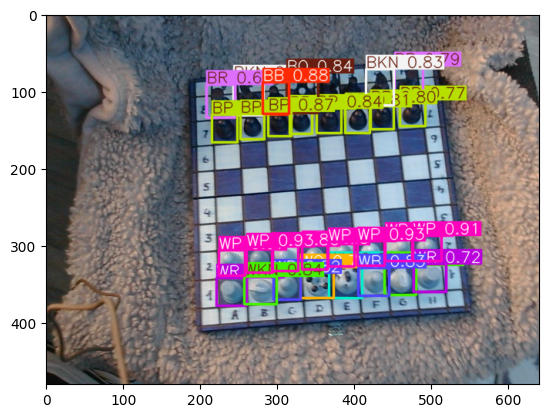

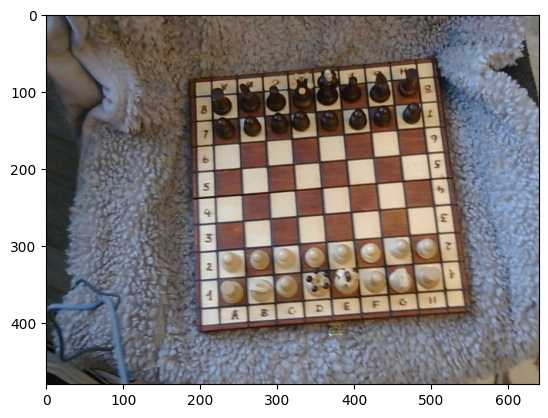

In [138]:
plt.imshow(result_pieces[0].plot())
plt.show()

image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()


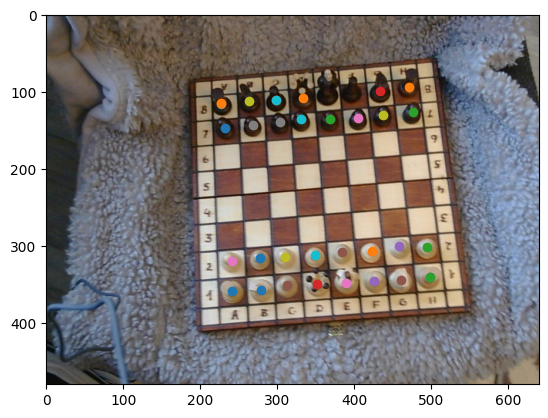

In [139]:
image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

for box in result_pieces[0].boxes.xywh:
    x,y,_,h = box.cpu()

    plt.scatter(x,y+h/2-20)

plt.show()

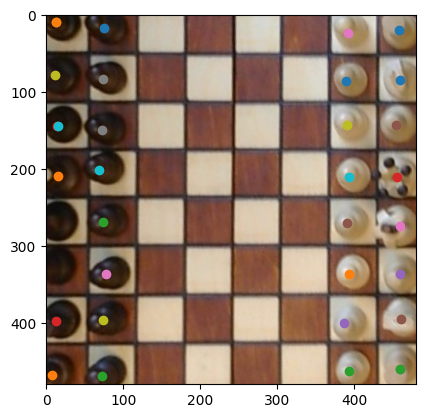

In [140]:
H = calculate_homography(result)
lower_y_coord = 20



image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.warpPerspective(image,H,(480,480))
plt.imshow(image)




for box in result_pieces[0].boxes.xywh:
    x,y,_,h = box.cpu()
    piece_pos = cv2.perspectiveTransform(np.array([[[x,y+h/2-lower_y_coord]]]), H).squeeze()
    plt.scatter(piece_pos[0],piece_pos[1])

plt.show()